<a href="https://colab.research.google.com/github/rhmputri/Short-Course-BPVP-Sidoarjo/blob/main/ShortCourse_Data_Science_for_IoT_Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Inisialisasi Library**



In [ ]:
!pip install pandas scikit-learn requests matplotlib

**Import Library**

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

**Ambil Data dari Firebase**

In [ ]:
url = "https://shortcourse-bpvp-task-3-default-rtdb.firebaseio.com/sensor.json"

response = requests.get(url)
raw_data = response.json()

print("Data Mentah dari Firebase")
print(raw_data)

Data Mentah dari Firebase
{'-OrksfdYxLXUgXlSnMNH': {'kelembaban': 40.0, 'suhu': 23.8}, '-OrktTE6fSkDIL-5JB4y': {'kelembaban': 42.0, 'suhu': 24.1}, '-Orktgsydb9Me4jxoHZ4': {'kelembaban': 41.0, 'suhu': 24.1}, '-OrktkbuDLZ_p6Jpb1b3': {'kelembaban': 40.0, 'suhu': 24.2}, '-OrktoYuTmc6bxqu_MQQ': {'kelembaban': 42.0, 'suhu': 23.8}, '-OrktuD4HkW-ojYxTbeY': {'kelembaban': 42.0, 'suhu': 24.0}, '-OrktzkIuA-otd4_GHaM': {'kelembaban': 38.0, 'suhu': 24.0}, '-Orku4QmYFqw68_mLc7l': {'kelembaban': 41.0, 'suhu': 24.2}, '-OrkuA2q3Y7kWxjP1l_i': {'kelembaban': 42.0, 'suhu': 23.9}, '-OrkuE1nwKJrk9jIXead': {'kelembaban': 41.0, 'suhu': 24.2}, '-OrkuH1glJ11kMHSprvf': {'kelembaban': 38.0, 'suhu': 24.1}, '-OrkuMZH2C-eoJcQF0ok': {'kelembaban': 40.0, 'suhu': 24.2}, '-OrkuS1aDmblMV3GhFsK': {'kelembaban': 39.0, 'suhu': 23.9}, '-OrkuWu2IdigeuDWSiGS': {'kelembaban': 41.0, 'suhu': 23.9}, '-OrkubZ-Qx1r9YFDMct0': {'kelembaban': 40.0, 'suhu': 24.1}, '-OrkufutrS13W87dKsn3': {'kelembaban': 40.0, 'suhu': 24.2}, '-OrkulUvM-w8

**Reset Value Database**

In [ ]:
clean_rows = []

for key, value in raw_data.items():
    if isinstance(value, dict) and 'sensor'in value:
      sensor_data = value['sensor']
      clean_rows.append(sensor_data)

df = pd.DataFrame(clean_rows)

print("DataFrame bersih")
print(df.head())
print("Kolom:", df.columns)

DataFrame bersih
Empty DataFrame
Columns: []
Index: []
Kolom: RangeIndex(start=0, stop=0, step=1)


In [ ]:
print("Isi Data:")
print(raw_data)

print("\nTipe data", type(raw_data))

Isi Data:
{'-OrksfdYxLXUgXlSnMNH': {'kelembaban': 40.0, 'suhu': 23.8}, '-OrktTE6fSkDIL-5JB4y': {'kelembaban': 42.0, 'suhu': 24.1}, '-Orktgsydb9Me4jxoHZ4': {'kelembaban': 41.0, 'suhu': 24.1}, '-OrktkbuDLZ_p6Jpb1b3': {'kelembaban': 40.0, 'suhu': 24.2}, '-OrktoYuTmc6bxqu_MQQ': {'kelembaban': 42.0, 'suhu': 23.8}, '-OrktuD4HkW-ojYxTbeY': {'kelembaban': 42.0, 'suhu': 24.0}, '-OrktzkIuA-otd4_GHaM': {'kelembaban': 38.0, 'suhu': 24.0}, '-Orku4QmYFqw68_mLc7l': {'kelembaban': 41.0, 'suhu': 24.2}, '-OrkuA2q3Y7kWxjP1l_i': {'kelembaban': 42.0, 'suhu': 23.9}, '-OrkuE1nwKJrk9jIXead': {'kelembaban': 41.0, 'suhu': 24.2}, '-OrkuH1glJ11kMHSprvf': {'kelembaban': 38.0, 'suhu': 24.1}, '-OrkuMZH2C-eoJcQF0ok': {'kelembaban': 40.0, 'suhu': 24.2}, '-OrkuS1aDmblMV3GhFsK': {'kelembaban': 39.0, 'suhu': 23.9}, '-OrkuWu2IdigeuDWSiGS': {'kelembaban': 41.0, 'suhu': 23.9}, '-OrkubZ-Qx1r9YFDMct0': {'kelembaban': 40.0, 'suhu': 24.1}, '-OrkufutrS13W87dKsn3': {'kelembaban': 40.0, 'suhu': 24.2}, '-OrkulUvM-w8a0iYUokr': {'kel

In [ ]:
sensor_data = raw_data.get('sensor', ())

#ubah data langsung ke DataFrame
df = pd.DataFrame.from_dict(raw_data, orient='index')

print("DataFrame awal:")
print(df.head())

DataFrame awal:
                      kelembaban  suhu
-OrksfdYxLXUgXlSnMNH        40.0  23.8
-OrktTE6fSkDIL-5JB4y        42.0  24.1
-Orktgsydb9Me4jxoHZ4        41.0  24.1
-OrktkbuDLZ_p6Jpb1b3        40.0  24.2
-OrktoYuTmc6bxqu_MQQ        42.0  23.8


In [ ]:
print(len(df))   #total data yg diambil

279


In [ ]:
df['suhu'] = pd.to_numeric(df['suhu'])
df['kelembaban'] = pd.to_numeric(df['kelembaban'])

print("Data siap Regresi :")
print(df.head())

Data siap Regresi :
                      kelembaban  suhu
-OrksfdYxLXUgXlSnMNH        40.0  23.8
-OrktTE6fSkDIL-5JB4y        42.0  24.1
-Orktgsydb9Me4jxoHZ4        41.0  24.1
-OrktkbuDLZ_p6Jpb1b3        40.0  24.2
-OrktoYuTmc6bxqu_MQQ        42.0  23.8


In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

#X variabel bebas
X = df[['kelembaban']]

#Y varibel target
y = df['suhu']

print("Ukuran X:", X.shape)
print("Ukuran Y", y.shape)


Ukuran X: (279, 1)
Ukuran Y (279,)


**Identifikasi Koefisien dan Prediksi Suhu Regresi Linear**

In [ ]:
model = LinearRegression()
model.fit(X, y)
df["Prediksi_Suhu"] = model.predict(X)

print("Koefisien (slope:)", model.coef_[0])
print("Intercept:", model.intercept_)
print("Prediksi Suhu", model.predict(X))

Koefisien (slope:) 0.48533163153799774
Intercept: 5.471253063377301
Prediksi Suhu [24.88451832 25.85518159 25.36984996 24.88451832 25.85518159 25.85518159
 23.91385506 25.36984996 25.85518159 25.36984996 23.91385506 24.88451832
 24.39918669 25.36984996 24.88451832 24.88451832 24.88451832 24.39918669
 24.39918669 23.91385506 25.36984996 24.88451832 23.91385506 24.39918669
 24.88451832 23.91385506 25.36984996 25.85518159 24.39918669 24.88451832
 23.91385506 24.88451832 25.85518159 24.88451832 23.91385506 25.36984996
 23.91385506 24.88451832 25.36984996 24.88451832 25.36984996 25.36984996
 25.85518159 23.91385506 24.39918669 25.85518159 23.91385506 24.39918669
 23.91385506 24.39918669 25.85518159 25.85518159 25.85518159 24.88451832
 23.91385506 24.88451832 24.88451832 24.39918669 24.39918669 25.36984996
 23.91385506 24.88451832 24.88451832 25.85518159 25.85518159 23.91385506
 23.91385506 25.85518159 25.85518159 25.36984996 24.39918669 25.36984996
 25.36984996 24.88451832 24.39918669 23.91

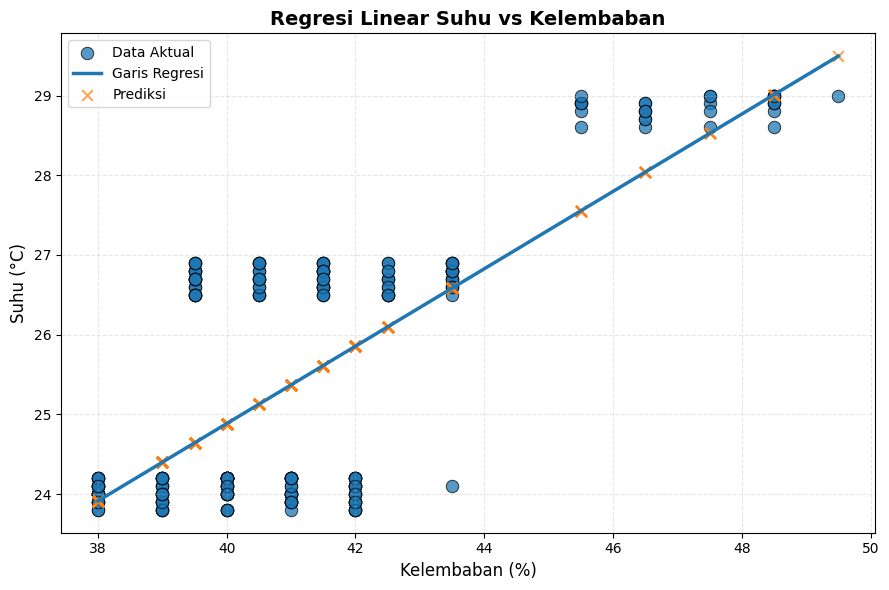

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

# Scatter plot (BEST STYLE)
plt.scatter(
        df["kelembaban"],
        df["suhu"],
        marker='o',           # clean & umum
        s=80,                 # ukuran pas
        alpha=0.75,           # transparansi
        edgecolors='black',   # outline biar jelas
        linewidths=0.7,
        label='Data Aktual'
    )

# Urutkan data agar garis halus
sorted_df = df.sort_values(by="kelembaban")

# Garis regresi
m, c = np.polyfit(sorted_df["kelembaban"], sorted_df["suhu"], 1)
plt.plot(
        sorted_df["kelembaban"],
        m * sorted_df["kelembaban"] + c,
        linestyle='-',
        linewidth=2.5,
        label='Garis Regresi'
    )

# Highlight titik prediksi
plt.scatter(
        df["kelembaban"],
        df["Prediksi_Suhu"],
        marker='x',
        s=60,
        alpha=0.7,
        label='Prediksi'
    )

# Styling biar clean
plt.title("Regresi Linear Suhu vs Kelembaban", fontsize=14, fontweight='bold')
plt.xlabel("Kelembaban (%)", fontsize=12)
plt.ylabel("Suhu (°C)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model_poly = LinearRegression()
model_poly.fit(X_poly, y)

df["Prediksi_Poly"] = model_poly.predict(X_poly)

print("Prediksi Poly:",model_poly.predict(X_poly))

Prediksi Poly: [24.8685183  25.69971224 25.26551289 24.8685183  25.69971224 25.69971224
 24.18614341 25.26551289 25.69971224 25.26551289 24.18614341 24.8685183
 24.50872847 25.26551289 24.8685183  24.8685183  24.8685183  24.50872847
 24.50872847 24.18614341 25.26551289 24.8685183  24.18614341 24.50872847
 24.8685183  24.18614341 25.26551289 25.69971224 24.50872847 24.8685183
 24.18614341 24.8685183  25.69971224 24.8685183  24.18614341 25.26551289
 24.18614341 24.8685183  25.26551289 24.8685183  25.26551289 25.26551289
 25.69971224 24.18614341 24.50872847 25.69971224 24.18614341 24.50872847
 24.18614341 24.50872847 25.69971224 25.69971224 25.69971224 24.8685183
 24.18614341 24.8685183  24.8685183  24.50872847 24.50872847 25.26551289
 24.18614341 24.8685183  24.8685183  25.69971224 25.69971224 24.18614341
 24.18614341 25.69971224 25.69971224 25.26551289 24.50872847 25.26551289
 25.26551289 24.8685183  24.50872847 24.18614341 24.8685183  25.26551289
 24.50872847 25.69971224 25.26551289 24

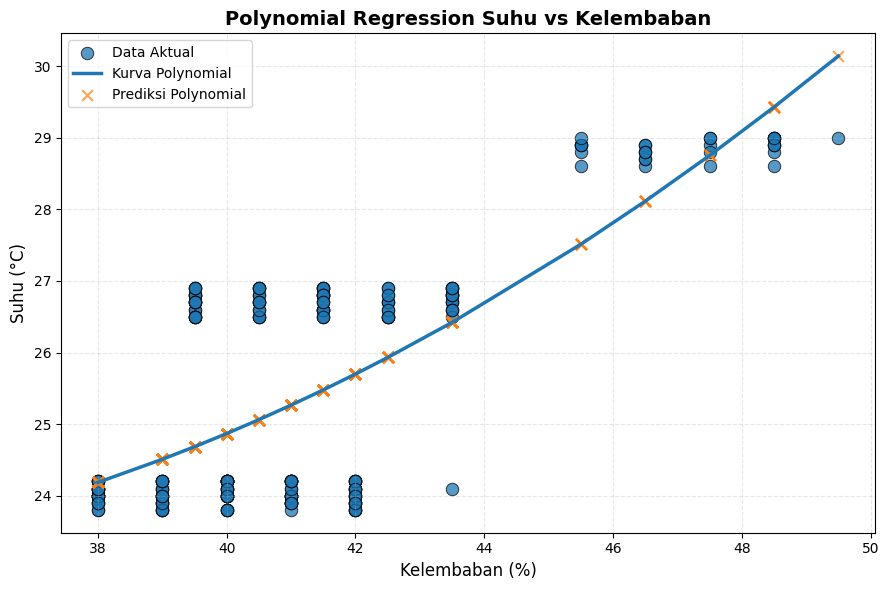

In [ ]:
plt.figure(figsize=(9, 6))

# Scatter data asli
plt.scatter(
      df["kelembaban"],
      df["suhu"],
      marker='o',
      s=80,
      alpha=0.75,
      edgecolors='black',
      linewidths=0.7,
      label='Data Aktual'
    )

# Urutkan untuk kurva halus
sorted_df = df.sort_values(by="kelembaban")

# Transform ke polynomial
X_sorted = sorted_df[["kelembaban"]]
X_sorted_poly = poly.transform(X_sorted)

# Prediksi polynomial (kurva)
y_poly_sorted = model_poly.predict(X_sorted_poly)

plt.plot(
      sorted_df["kelembaban"],
      y_poly_sorted,
      linestyle='-',
      linewidth=2.5,
      label='Kurva Polynomial'
    )

# Titik prediksi
plt.scatter(
        df["kelembaban"],
        df["Prediksi_Poly"],
        marker='x',
        s=60,
        alpha=0.7,
      label='Prediksi Polynomial'
    )

plt.title("Polynomial Regression Suhu vs Kelembaban", fontsize=14, fontweight='bold')
plt.xlabel("Kelembaban (%)", fontsize=12)
plt.ylabel("Suhu (°C)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()